# Gate Execution Quality Metrics

This tutorial covers benchmarks for measuring quantum gate performance.

In [21]:
from qcmet import CliffordRB, InterleavedRB, OverUnderRotationAngle, CycleBenchmarking
from qcmet.devices import NoisySimulator, IdealSimulator
import matplotlib.pyplot as plt
import numpy as np

The gate execution quality metrics consist of:

- Gate set tomography based process fidelity (GST)

- Clifford randomised benchmarking (CliffordRB)

- Interleaved Clifford randomised benchmarking (InterleavedRB)

- Cycle-benchmarking composite process fidelity (CycleBenchmarking)

- Over- or under-rotation angle (OverUnderRotationAngle)

## Clifford Randomized Benchmarking (RB)

Clifford Randomized Benchmarking measures the average error rate of a gate set by applying random sequences of Clifford gates.

### How Clifford RB Works

1. Generate random sequences of Clifford gates of varying lengths
2. Append an inverse gate to return to |0⟩
3. Measure success probability
4. Fit decay curve: P(success) = A × p^m + B
5. Extract average gate error from decay parameter p

In [22]:
# Create simulator
noisy_device = NoisySimulator()

# Setup CliffordRB benchmark
rb = CliffordRB(
    qubits=2,
    m_list = [25,50,100,150,200,250,300,400,500,650],
    circs_per_m=10
)

# Generate circuits
rb.generate_circuits()
print(rb.config)
print(f"Generated {len(rb.circuits)} circuits")
print(f"Total circuits: {len(rb.config['m_list'])} lengths × {rb.config['circs_per_m']} samples")

{'m_list': [25, 50, 100, 150, 200, 250, 300, 400, 500, 650], 'circs_per_m': 10, 'interleaved_clifford': None}
Generated 100 circuits
Total circuits: 10 lengths × 10 samples


In [23]:
# Look at circuit structure
print("Example RB circuit:")
print(rb.circuits[10])

Example RB circuit:
              ░         ░       ░ ┌────────┐ ░       ░       ░ ┌───┐ ░        »
   q_0: ──────░─────────░───────░─┤0       ├─░───────░───■───░─┤ Z ├─░────────»
        ┌───┐ ░ ┌─────┐ ░ ┌───┐ ░ │  Iswap │ ░ ┌───┐ ░ ┌─┴─┐ ░ └───┘ ░ ┌─────┐»
   q_1: ┤ Z ├─░─┤ Sdg ├─░─┤ Y ├─░─┤1       ├─░─┤ Z ├─░─┤ Y ├─░───────░─┤ Sdg ├»
        └───┘ ░ └─────┘ ░ └───┘ ░ └────────┘ ░ └───┘ ░ └───┘ ░       ░ └─────┘»
meas: 2/══════════════════════════════════════════════════════════════════════»
                                                                              »
«         ░       ░ ┌───┐ ░ ┌───┐ ░       ░     ░ ┌──────┐ ░       ░ ┌───┐ ░ »
«   q_0: ─░───────░─┤ Y ├─░─┤ X ├─░───────░──■──░─┤0     ├─░───────░─┤ X ├─░─»
«         ░ ┌───┐ ░ └─┬─┘ ░ └─┬─┘ ░ ┌───┐ ░  │  ░ │  Ecr │ ░ ┌───┐ ░ └───┘ ░ »
«   q_1: ─░─┤ X ├─░───■───░───■───░─┤ Z ├─░──■──░─┤1     ├─░─┤ Z ├─░───────░─»
«         ░ └───┘ ░       ░       ░ └───┘ ░     ░ └──────┘ ░ └───┘ ░       ░ »
«meas: 2/════════════════

In [24]:
# Run benchmark
rb.run(noisy_device, num_shots=1024)

# Analyze
results = rb.analyze()
print("\nRB Results:")
for key, value in results.items():
    print(f"  {key}: {value}")


RB Results:
  qubits: 2
  alpha: 0.9996772896169319
  AverageGateError: 0.00024
  fit_result: {'popt': array([0.99967729, 0.67568573, 0.32379839]), 'pcov': array([[ 2.18584749e-08,  4.11562949e-05, -4.12954106e-05],
       [ 4.11562949e-05,  7.75766023e-02, -7.78317533e-02],
       [-4.12954106e-05, -7.78317533e-02,  7.80885979e-02]])}


### Visualizing RB Decay

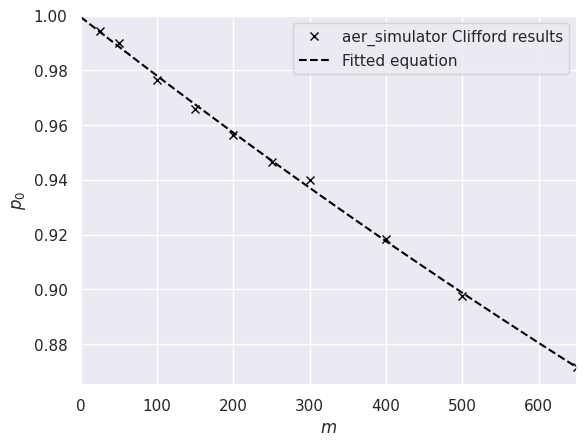

In [25]:
# Plot
rb.plot()
plt.show()

### Comparing Gate Quality

Let's compare gate quality between ideal and noisy simulators:

In [30]:
# Run RB on noisy simulator
ideal_device = IdealSimulator()

rb_noiseless = CliffordRB(
    qubits=2,
    m_list = [25,50,100,150,200,250,300,400,500,650],
    circs_per_m=10
)

rb_noiseless.generate_circuits()
rb_noiseless.run(ideal_device, num_shots=1024)

results_ideal = rb_noiseless.analyze()

print("\nComparison:")
print(f"Average gate error ideal: {results_ideal.get('AverageGateError', 'N/A')}")
print(f"Average gate error noisy simulator: {results.get('AverageGateError', 'N/A')}")


Comparison:
Average gate error ideal: -0.00000
Average gate error noisy simulator: 0.00024


### What the Numbers Mean

**Average Gate Error**: Average gate error of a set of single- and multi-qubit Clifford gates
- The lower the Average Gate Error, the better the quality of Clifford operations.

## Interleaved Clifford Randomized Benchmarking (RB)

Interleaved Clifford Randomized Benchmarking measures the average error rate of a target Clifford gate in a gate set. This is done by interleaving a target Clifford gate through random sequences of Clifford gates.

### How Interleaved RB Works

1. Generate random sequences of Clifford gates of varying lengths
2. Append an inverse gate to return to |0⟩
3. Measure success probability
4. Fit decay curve: P(success) = A × p^m + B
5. Extract average gate error from decay parameter p
6. Generate random sequences of Clifford gates of varying lengths interleaved with target Clifford gate
7. Repeat steps 2-5 to extract the decay parameter p_i for the interleaved circuits.
8. Calculate interleaved gate error using the decay parameters p and p_i.

In [33]:
from qiskit import QuantumCircuit

# Create simulator
device = NoisySimulator()

# Create circuit with target Clifford gate
circ = QuantumCircuit(1)
circ.x(0)

# Setup interleavedRB benchmark
irb = InterleavedRB(
    qubits=1,
    m_list = [25,50,100,150,200,250,300,400,500,650],
    circs_per_m=10,
    interleaved_clifford=circ
)

# Generate circuits
irb.generate_circuits()
print(irb.config)
print(f"Generated {len(irb.circuits)} circuits")
print(f"Total circuits: {len(irb.config['m_list'])} lengths × {irb.config['circs_per_m']} samples")

{'m_list': [25, 50, 100, 150, 200, 250, 300, 400, 500, 650], 'circs_per_m': 10, 'interleaved_clifford': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7f1403d07380>}
Generated 200 circuits
Total circuits: 10 lengths × 10 samples


In [34]:
# Run benchmark
irb.run(device, num_shots=1024)

# Analyze
results = irb.analyze()
print("\nIRB Results:")
for key, value in results.items():
    print(f"  {key}: {value}")


IRB Results:
  qubits: 1
  alpha: 0.9999235760656404
  alpha_g: 0.9995476221471704
  AverageGateError: 0.00004
  InterleavedGateError: 0.00019
  Clifford_fit: {'fit_result': {'popt': array([0.99992358, 1.        , 0.00125025]), 'pcov': array([[ 6.44838319e-08,  8.23109620e-04, -8.23263413e-04],
       [ 8.23109620e-04,  1.05072126e+01, -1.05091647e+01],
       [-8.23263413e-04, -1.05091647e+01,  1.05111175e+01]])}}
  Interleaved_fit: {'fit_result': {'popt': array([0.99954762, 0.51257069, 0.48753614]), 'pcov': array([[ 3.74777624e-08,  3.65497812e-05, -3.67946455e-05],
       [ 3.65497812e-05,  3.57284630e-02, -3.59581700e-02],
       [-3.67946455e-05, -3.59581700e-02,  3.61909435e-02]])}}


### Visualizing InterleavedRB Decay

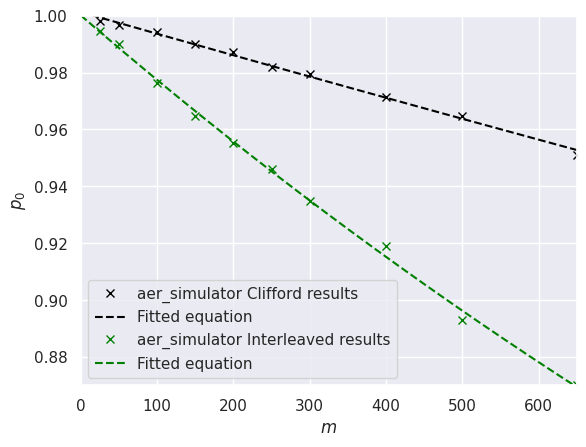

In [35]:
# Plot
irb.plot()
plt.show()

### What the Numbers Mean

**Average Gate Error**: Average gate error of a set of single- and multi-qubit Clifford gates
- The lower the Average Gate Error, the better the quality of Clifford operations.

**Interleaved Gate Error**: Average gate error of a target Clifford gate in a gate set
- The lower the Interleaved Gate Error, the better the quality of the target Clifford operation.

## Over/Under Rotation Angle

This benchmark detects systematic over-rotation or under-rotation errors in single-qubit gates.

Generated 41 circuits

Rotation Analysis Results:
  success: True
  OverUnderRotationAngle: 0.03146251398870455
  fit_result: {'popt': array([ 0.50052081, -0.5020418 ,  0.02107131,  0.12585006,  1.5753996 ]), 'pcov': array([[ 4.51268404e-06,  5.94109362e-06, -2.59998197e-07,
         9.94502958e-08, -2.85527367e-06],
       [ 5.94109362e-06,  1.81765069e-04, -7.86083103e-06,
        -9.72212447e-07,  5.47409729e-05],
       [-2.59998197e-07, -7.86083103e-06,  6.01151691e-07,
         3.84869866e-08, -2.25924771e-06],
       [ 9.94502958e-08, -9.72212447e-07,  3.84869866e-08,
         4.30265278e-07, -8.18183895e-06],
       [-2.85527367e-06,  5.47409729e-05, -2.25924771e-06,
        -8.18183895e-06,  3.98614943e-04]])}


(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Fitting with error amount = 0.031$\\pi$'}, xlabel='$m$', ylabel='$p_0$'>)

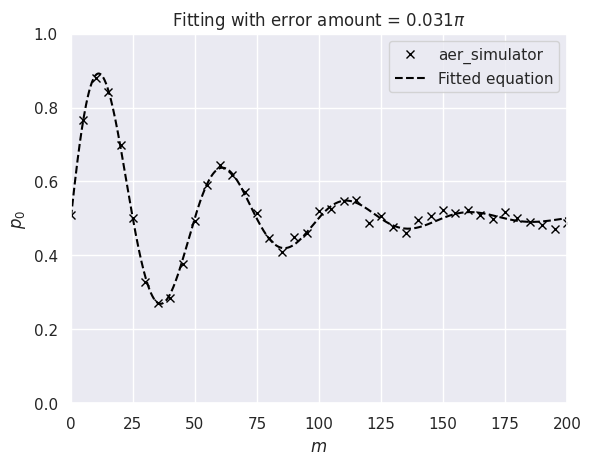

In [36]:
overrotation_amount= np.pi/100
device = NoisySimulator(t1=0, t2=0, overrotation_amount=overrotation_amount)

rotation_exp = OverUnderRotationAngle(
    qubits=1,
    delta_m=5,  # Maximum gate repetitions
)

# Generate and run
rotation_exp.generate_circuits()
print(f"Generated {len(rotation_exp.circuits)} circuits")

rotation_exp.run(device, num_shots=1024)
results_rot = rotation_exp.analyze()

print("\nRotation Analysis Results:")
for key, value in results_rot.items():
    print(f"  {key}: {value}")
rotation_exp.plot()

### What the Numbers Mean
**Over/Under Rotation Angle** (in radians): The amount of over/under- rotation per gate
- A positive value represents an over-rotation by the target gate.
- A negative value represents an under-rotation by the target gate.
- The larger the magnitude of over/under- rotation, the lower the accuracy of the gate rotation.

## Further benchmarks

Additional gate quality metrics implemented in QCMet are

- Gate set tomography based process fidelity (GST)
- Cycle-benchmarking composite process fidelity (CycleBenchmarking)

These also follow the standard workflow:

{'composite_process_fidelity': {'m=2_to_m=4': 4.03307128518151,
  'm=2_to_m=8': 1.1263552467649778,
  'm=2_to_m=10': 0.5437854647893269,
  'm=4_to_m=8': 0.49965640854839666,
  'm=4_to_m=10': 0.5190481243612284,
  'm=8_to_m=10': 0.40691147471081385},
 'method': 'ratio',
 'success': True,
 'ptm_elements': {2: {'XX': 0.99765625,
   'XY': 0.0185546875,
   'XZ': 0.00625,
   'XI': 0.015234375,
   'YX': 0.998046875,
   'YY': 0.0009765625,
   'YZ': -0.016015625,
   'YI': 0.99921875,
   'ZX': 0.9974609375,
   'ZY': -0.019140625,
   'ZZ': -0.0017578125,
   'ZI': -0.0140625,
   'IX': 0.998828125,
   'IY': 0.0033203125,
   'IZ': -0.007421875},
  4: {'XX': 0.9947265625,
   'XY': -0.9947265625,
   'XZ': -0.9947265625,
   'XI': 0.994921875,
   'YX': 0.996875,
   'YY': -0.9943359375,
   'YZ': -0.9951171875,
   'YI': 0.9962890625,
   'ZX': 0.9958984375,
   'ZY': -0.9955078125,
   'ZZ': -0.994140625,
   'ZI': 0.99375,
   'IX': 0.99765625,
   'IY': -0.994921875,
   'IZ': -0.9947265625},
  8: {'XX': 0.992

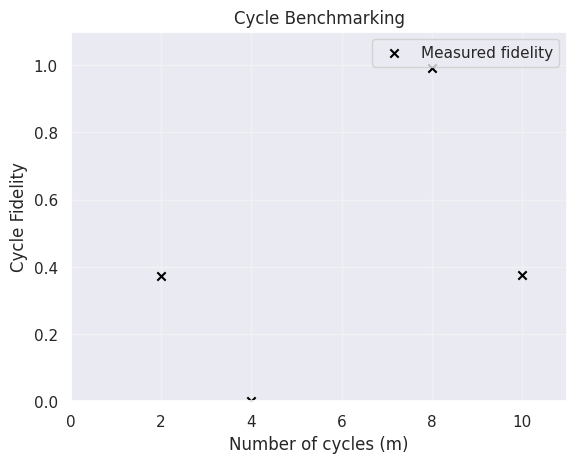

In [45]:
device = NoisySimulator()

# gate layer to benchmark
circ = QuantumCircuit(2)
circ.h(0)
circ.cx(0, 1)
circ.x(1)

cyclebm = CycleBenchmarking(circ, [2, 4, 8, 10])

cyclebm(device)